In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('chicago_crime_cleaned.csv')

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 1. Weekend flag ---
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday']).astype(int)

# --- 2. Season based on month ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# --- 3. Coordinate binning ---
df['lat_bin'] = df['Latitude'].round(2)
df['lon_bin'] = df['Longitude'].round(2)

# --- 4. Crime severity score ---
severity_map = {
    'HOMICIDE': 5,
    'CRIMINAL SEXUAL ASSAULT': 4,
    'ROBBERY': 4,
    'ASSAULT': 3,
    'BATTERY': 3,
    'BURGLARY': 3,
    'THEFT': 2,
    'MOTOR VEHICLE THEFT': 2,
    'NARCOTICS': 2,
    'OTHER OFFENSE': 1
}
df['severity_score'] = df['Primary Type'].map(severity_map).fillna(1)

# --- 5. One-hot encode categorical columns ---
categorical_cols = ['Primary Type', 'Location Description', 'weekday', 'season']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- 6. Normalize coordinates (no ML yet, just scaling) ---
scaler = StandardScaler()
df[['Latitude', 'Longitude']] = scaler.fit_transform(df[['Latitude', 'Longitude']])

print("✅ Feature Engineering complete!")
print("Shape:", df.shape)
print("Sample of new columns:", ['is_weekend', 'season', 'lat_bin', 'lon_bin', 'severity_score'])

df.to_csv("chicago_final_data.csv", index=False)

print("✅ Feature-engineered dataset saved successfully")
print("Rows:", df.shape[0], " | Columns:", df.shape[1])


✅ Feature Engineering complete!
Shape: (467756, 226)
Sample of new columns: ['is_weekend', 'season', 'lat_bin', 'lon_bin', 'severity_score']
✅ Feature-engineered dataset saved successfully
Rows: 467756  | Columns: 226


✅ PCA Completed Successfully!
Original Features: 17
Reduced Components: 7
Total Variance Retained: 84.83%


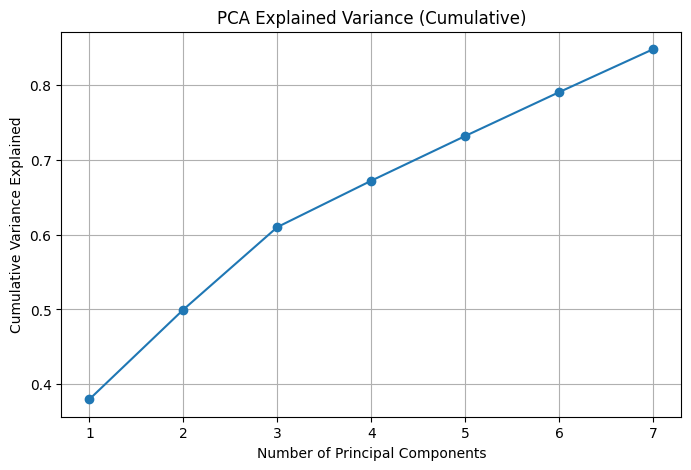

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 1. Load the feature-engineered dataset ---
df = pd.read_csv(r"C:\Users\hameedbf\Documents\Python\chicago_crime_pattern\chicago_final_data.csv")

# --- 2. Select only numeric columns ---
df_numeric = df.select_dtypes(include=['number'])

# --- 3. Scale the numeric features (important for PCA) ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# --- 4. Apply PCA to retain 80% of variance ---
pca = PCA(n_components=0.80, random_state=42)
pca_data = pca.fit_transform(scaled_data)

# --- 5. Create a PCA DataFrame ---
pca_df = pd.DataFrame(pca_data, columns=[f"PC{i+1}" for i in range(pca_data.shape[1])])

# --- 6. Save reduced data for clustering ---
pca_df.to_csv("chicago_pca_reduced.csv", index=False)

# --- 7. Print PCA summary ---
print("✅ PCA Completed Successfully!")
print(f"Original Features: {df_numeric.shape[1]}")
print(f"Reduced Components: {pca_df.shape[1]}")
print(f"Total Variance Retained: {pca.explained_variance_ratio_.sum():.2%}")

# --- 8. Scree Plot: Variance Explained by Each Component ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title("PCA Explained Variance (Cumulative)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()


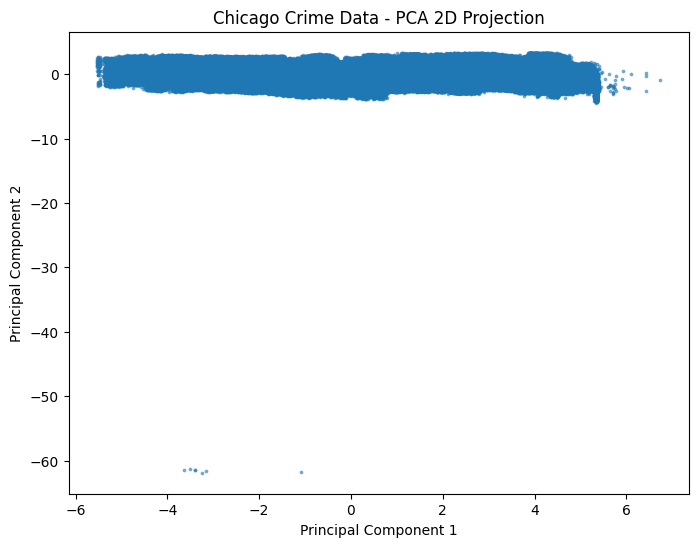

In [2]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=3, alpha=0.5)
plt.title("Chicago Crime Data - PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


Running optimized t-SNE on 10k sample...
Running UMAP on full dataset (faster)...
UMAP(min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Nov  3 20:24:54 2025 Construct fuzzy simplicial set


c:\Users\hameedbf\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Nov  3 20:24:54 2025 Finding Nearest Neighbors
Mon Nov  3 20:24:54 2025 Building RP forest with 39 trees
Mon Nov  3 20:25:24 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	Stopping threshold met -- exiting after 2 iterations
Mon Nov  3 20:26:47 2025 Finished Nearest Neighbor Search
Mon Nov  3 20:26:55 2025 Construct embedding


Epochs completed:   0%|            1/200 [00:01]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [11:33]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [12:40]


Mon Nov  3 20:44:02 2025 Finished embedding


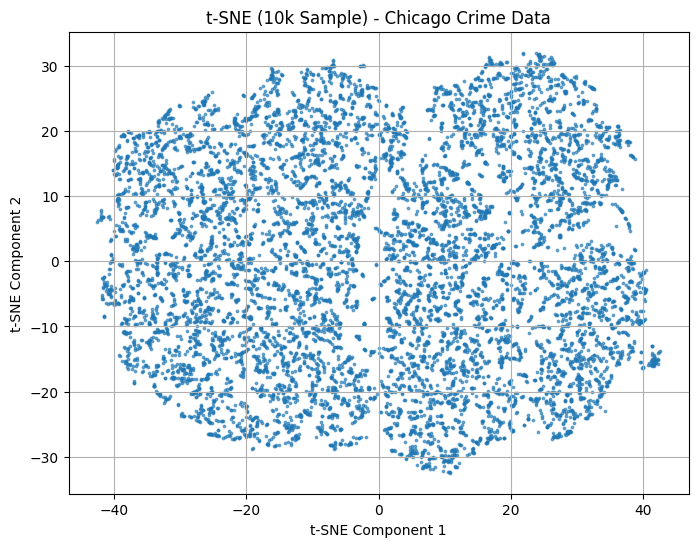

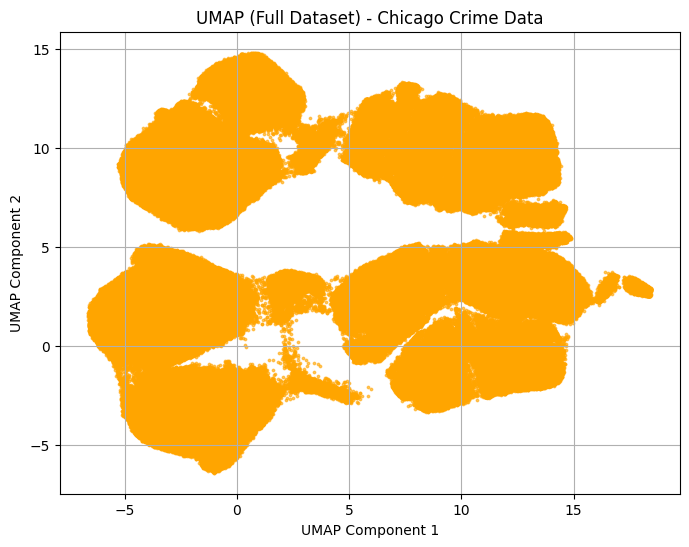

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap


# --- 1. Load PCA reduced data ---
pca_df = pd.read_csv("chicago_pca_reduced.csv")

# --- 2. Take a representative sample (for speed) ---
# Sampling ~10,000 rows gives a good balance between detail and performance
sample_df = pca_df.sample(n=10000, random_state=42)

# --- 3. Apply t-SNE (optimized for large data) ---
print("Running optimized t-SNE on 10k sample...")
tsne = TSNE(
    n_components=2,
    perplexity=30,      # lower for small samples
    random_state=42,
    max_iter=500,       # fewer iterations for faster convergence
    learning_rate='auto',
    init='pca',         # better initialization
    n_jobs=-1           # parallel computation if available
)
tsne_results = tsne.fit_transform(sample_df)

# --- 4. Apply UMAP (faster alternative, on full or sample data) ---
print("Running UMAP on full dataset (faster)...")
umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.3,
    verbose=True
)
umap_results = umap_reducer.fit_transform(pca_df)

# --- 5. Create visualization DataFrames ---
tsne_viz = pd.DataFrame(tsne_results, columns=['tSNE-1', 'tSNE-2'])
umap_viz = pd.DataFrame(umap_results, columns=['UMAP-1', 'UMAP-2'])

# --- 6. Plot t-SNE ---
plt.figure(figsize=(8,6))
plt.scatter(tsne_viz['tSNE-1'], tsne_viz['tSNE-2'], s=3, alpha=0.6)
plt.title("t-SNE (10k Sample) - Chicago Crime Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

# --- 7. Plot UMAP ---
plt.figure(figsize=(8,6))
plt.scatter(umap_viz['UMAP-1'], umap_viz['UMAP-2'], s=3, alpha=0.6, color='orange')
plt.title("UMAP (Full Dataset) - Chicago Crime Data")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True)
plt.show()
